# Bloque 2 - NLP: Modelos Avanzados
## Word2Vec + BiLSTM | DistilBERT
**Proyecto:** Segmentación de células e interpretación de texto mediante modelos de deep learning  
**Requiere:** `artifacts/` generados en `01_EDA_NLP_Resume.ipynb`  
**Continúa:** `results_table` del notebook `02_Modelos_Simples_NLP.ipynb`

## 0. Importaciones y configuración

In [1]:
# ============================================================
# DEBE SER LA PRIMERA CELDA — antes de cualquier import
# ============================================================
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import pickle
import warnings

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import Word2Vec
from transformers import (
    DistilBertTokenizerFast,
    TFDistilBertForSequenceClassification,
    create_optimizer
)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import StratifiedKFold

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Importar callbacks desde tf_keras para compatibilidad con transformers
import tf_keras
from tensorflow.keras import layers, models, callbacks


warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs disponibles: {len(gpus)}')
for g in gpus:
    print(f'  {g}')
print(f'TensorFlow: {tf.__version__}')

2026-05-10 18:46:20.956131: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-10 18:46:21.420089: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-10 18:46:25.090648: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/alejo/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/tqdm

GPUs disponibles: 1
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
TensorFlow: 2.20.0


## 1. Carga de artefactos

In [2]:
ARTIFACTS = 'artifacts/'

X_train = np.load(ARTIFACTS + 'X_train.npy')
X_val   = np.load(ARTIFACTS + 'X_val.npy')
X_test  = np.load(ARTIFACTS + 'X_test.npy')
y_train = np.load(ARTIFACTS + 'y_train.npy')
y_val   = np.load(ARTIFACTS + 'y_val.npy')
y_test  = np.load(ARTIFACTS + 'y_test.npy')

with open(ARTIFACTS + 'tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
with open(ARTIFACTS + 'label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)
with open(ARTIFACTS + 'config.pkl', 'rb') as f:
    config = pickle.load(f)

MAX_LEN     = config['MAX_LEN']
VOCAB_SIZE  = config['VOCAB_SIZE']
NUM_CLASSES = config['NUM_CLASSES']
CLASSES     = config['CLASSES']

print(f'MAX_LEN={MAX_LEN} | VOCAB_SIZE={VOCAB_SIZE} | NUM_CLASSES={NUM_CLASSES}')
print(f'Train/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)}')

MAX_LEN=100 | VOCAB_SIZE=20000 | NUM_CLASSES=24
Train/Val/Test: 1738/373/373


In [3]:
# Reconstruir texto limpio desde secuencias (necesario para Word2Vec y DistilBERT)
idx2word = {v: k for k, v in tokenizer.word_index.items()}

def sequences_to_text(seq_matrix):
    texts = []
    for seq in seq_matrix:
        words = [idx2word.get(i, '') for i in seq if i != 0]
        texts.append(' '.join(words))
    return np.array(texts)

text_train = sequences_to_text(X_train)
text_val   = sequences_to_text(X_val)
text_test  = sequences_to_text(X_test)
print('Textos reconstruidos.')

Textos reconstruidos.


In [4]:
# results_table con métricas de los modelos anteriores (del notebook 02)
# Pegar aquí el diccionario impreso al final del notebook anterior.
# Formato: {'Modelo': {'Accuracy': x, 'Precision': x, 'Recall': x, 'F1': x, 'ROC-AUC': x}}
results_table = {
    'TF-IDF + XGBoost' : {'Accuracy': 0.4477, 'Precision': 0.4478, 'Recall': 0.4477, 'F1': 0.3670, 'ROC-AUC': 0.7943},
    'FastText + XGBoost': {'Accuracy': 0.5255, 'Precision': 0.5261, 'Recall': 0.5255, 'F1': 0.5044, 'ROC-AUC': 0.8968},
    'CNN-1D'            : {'Accuracy': 0.7212, 'Precision': 0.7101, 'Recall': 0.7212, 'F1': 0.6965, 'ROC-AUC': 0.9496},
}
print('results_table inicializado con métricas del notebook 02.')

results_table inicializado con métricas del notebook 02.


## 2. Utilidades de evaluación
Mismas métricas obligatorias (Sección 11.20.6.6).  
**Cambio respecto al notebook 02:** la matriz de confusión va en figura propia con tamaño adaptado al número de clases.

In [5]:
def compute_metrics(y_true, y_pred, y_proba, classes):
    avg = 'weighted'
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average=avg, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, average=avg, zero_division=0),
        'F1'       : f1_score(y_true, y_pred, average=avg, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_true, y_proba, multi_class='ovr',
                                   average=avg, labels=list(range(len(classes))))
    }


def plot_confusion_matrix(y_true, y_pred, classes, model_name):
    """
    Figura independiente para la matriz de confusión.
    Tamaño escalado al número de clases para legibilidad.
    """
    n = len(classes)
    fig_size = max(10, n * 0.7)          # mínimo 10, crece con el nº de clases
    font_size = max(7, 11 - n // 5)     # fuente más pequeña si hay muchas clases

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizada por fila

    fig, axes = plt.subplots(1, 2, figsize=(fig_size * 2, fig_size))

    for ax, data, fmt, title_suffix in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        ['(conteos absolutos)', '(normalizada por fila)']
    ):
        sns.heatmap(
            data, annot=True, fmt=fmt, cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            ax=ax, linewidths=0.4,
            annot_kws={'size': font_size}
        )
        ax.set_xlabel('Predicho', fontsize=font_size + 1)
        ax.set_ylabel('Real', fontsize=font_size + 1)
        ax.set_title(f'{model_name} — Matriz de confusión {title_suffix}',
                     fontsize=font_size + 2, fontweight='bold')
        ax.tick_params(axis='x', rotation=45, labelsize=font_size)
        ax.tick_params(axis='y', rotation=0,  labelsize=font_size)

    plt.tight_layout()
    plt.show()


def plot_roc_pr(y_true, y_proba, classes, model_name):
    """
    Figura independiente con curva ROC y Precision-Recall (macro OvR).
    """
    n_classes = len(classes)
    y_true_bin = np.eye(n_classes)[y_true]
    mean_fpr = np.linspace(0, 1, 200)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ROC
    tprs, aucs = [], []
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        aucs.append(auc(fpr, tpr))
    mean_tpr = np.mean(tprs, axis=0)
    axes[0].plot(mean_fpr, mean_tpr, color='steelblue', linewidth=2,
                 label=f'Macro AUC = {np.mean(aucs):.3f}')
    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[0].set(xlabel='FPR', ylabel='TPR',
                title=f'{model_name} — Curva ROC (macro OvR)')
    axes[0].legend(loc='lower right')

    # Precision-Recall
    mean_recall = np.linspace(0, 1, 200)
    precs_interp, aps = [], []
    for i in range(n_classes):
        prec, rec, _ = precision_recall_curve(y_true_bin[:, i], y_proba[:, i])
        precs_interp.append(np.interp(mean_recall[::-1], rec[::-1], prec[::-1])[::-1])
        aps.append(average_precision_score(y_true_bin[:, i], y_proba[:, i]))
    axes[1].plot(mean_recall, np.mean(precs_interp, axis=0),
                 color='seagreen', linewidth=2,
                 label=f'Macro AP = {np.mean(aps):.3f}')
    axes[1].set(xlabel='Recall', ylabel='Precision',
                title=f'{model_name} — Curva Precision-Recall (macro OvR)')
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()


def evaluate_model(y_true, y_pred, y_proba, classes, model_name):
    """Wrapper: métricas + matriz de confusión (figura propia) + ROC/PR."""
    metrics = compute_metrics(y_true, y_pred, y_proba, classes)

    print(f'\n=== {model_name} — Métricas en TEST ===')
    for k, v in metrics.items():
        print(f'  {k:<12}: {v:.4f}')
    print('\n', classification_report(y_true, y_pred,
                                      target_names=classes, zero_division=0))

    plot_confusion_matrix(y_true, y_pred, classes, model_name)
    plot_roc_pr(y_true, y_proba, classes, model_name)

    return metrics


print('Utilidades de evaluación cargadas.')

Utilidades de evaluación cargadas.


---
## Modelo 4: Word2Vec + BiLSTM
Sección 11.20.6.3, posición 2. Word2Vec se entrena sobre el corpus propio y luego se usa como capa Embedding congelada en el BiLSTM.

### 4.1 Entrenamiento de Word2Vec

In [6]:
# Hiperparámetros Word2Vec (Sección 11.20.6.4: embedding_dim 100 o 200)
W2V_DIM    = 200
W2V_WINDOW = 5
W2V_MIN_COUNT = 2
W2V_WORKERS   = 4
W2V_EPOCHS    = 10

# Corpus: listas de tokens por documento
corpus_train = [text.split() for text in text_train]
corpus_all   = corpus_train + [t.split() for t in text_val]  # val también para vocabulario

w2v_model = Word2Vec(
    sentences=corpus_all,
    vector_size=W2V_DIM,
    window=W2V_WINDOW,
    min_count=W2V_MIN_COUNT,
    workers=W2V_WORKERS,
    seed=RANDOM_SEED,
    epochs=W2V_EPOCHS
)

print(f'Word2Vec entrenado.')
print(f'  Vocabulario W2V : {len(w2v_model.wv):,} tokens')
print(f'  Dimensión       : {W2V_DIM}')

# Guardar Word2Vec
os.makedirs('models', exist_ok=True)
w2v_model.save('models/word2vec.model')
print('Word2Vec guardado en models/word2vec.model')

Word2Vec entrenado.
  Vocabulario W2V : 7,516 tokens
  Dimensión       : 200
Word2Vec guardado en models/word2vec.model


### 4.2 Construcción de la matriz de embeddings

In [7]:
def build_embedding_matrix(tokenizer_word_index, w2v_wv, vocab_size, embed_dim):
    """
    Construye la matriz de embeddings para la capa Keras Embedding.
    Tokens no encontrados en W2V se inicializan con ceros.
    """
    matrix = np.zeros((vocab_size + 1, embed_dim), dtype=np.float32)
    found, not_found = 0, 0
    for word, idx in tokenizer_word_index.items():
        if idx > vocab_size:
            continue
        if word in w2v_wv:
            matrix[idx] = w2v_wv[word]
            found += 1
        else:
            not_found += 1
    coverage = found / (found + not_found) * 100
    print(f'Cobertura W2V: {found:,} encontrados / {not_found:,} no encontrados ({coverage:.1f}%)')
    return matrix

embedding_matrix = build_embedding_matrix(
    tokenizer.word_index, w2v_model.wv, VOCAB_SIZE, W2V_DIM
)
print(f'Embedding matrix shape: {embedding_matrix.shape}')

Cobertura W2V: 7,516 encontrados / 12,484 no encontrados (37.6%)
Embedding matrix shape: (20001, 200)


### 4.3 Arquitectura BiLSTM

In [8]:
# Hiperparámetros BiLSTM (Sección 11.20.6.4)
LSTM_UNITS      = 128
NUM_LSTM_LAYERS = 2
DROPOUT_RATE    = 0.3
LEARNING_RATE   = 0.001
BATCH_SIZE      = 64
EPOCHS          = 50


def build_bilstm(embedding_matrix, max_len, num_classes,
                 lstm_units, num_layers, dropout_rate):
    """
    BiLSTM apilado con embeddings W2V preentrenados (no entrenable).
    Arquitectura: Embedding(frozen) → BiLSTM x N → Dropout → Dense → Softmax
    """
    vocab_sz, embed_dim = embedding_matrix.shape

    inputs = layers.Input(shape=(max_len,), name='input_seq')

    x = layers.Embedding(
        input_dim=vocab_sz,
        output_dim=embed_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False,          # embeddings W2V congelados
        name='w2v_embedding'
    )(inputs)

    x = layers.SpatialDropout1D(dropout_rate)(x)

    for i in range(num_layers):
        return_seq = (i < num_layers - 1)   # True en todas menos la última capa
        x = layers.Bidirectional(
            layers.LSTM(lstm_units, return_sequences=return_seq,
                        dropout=dropout_rate),
            name=f'bilstm_{i+1}'
        )(x)

    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(256, activation='relu', name='dense1')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return models.Model(inputs, outputs, name='BiLSTM_W2V')


bilstm_model = build_bilstm(
    embedding_matrix, MAX_LEN, NUM_CLASSES,
    LSTM_UNITS, NUM_LSTM_LAYERS, DROPOUT_RATE
)
bilstm_model.summary()

I0000 00:00:1778456793.379999   36760 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "BiLSTM_W2V"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_seq (InputLayer)      [(None, 100)]             0         
                                                                 
 w2v_embedding (Embedding)   (None, 100, 200)          4000200   
                                                                 
 spatial_dropout1d (Spatial  (None, 100, 200)          0         
 Dropout1D)                                                      
                                                                 
 bilstm_1 (Bidirectional)    (None, 100, 256)          336896    
                                                                 
 bilstm_2 (Bidirectional)    (None, 256)               394240    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                        

### 4.4 Entrenamiento BiLSTM

In [9]:
bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cbs = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=6,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    )
]

history_bilstm = bilstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cbs,
    verbose=1
)

Epoch 1/50


2026-05-10 18:46:35.934127: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
2026-05-10 18:46:36.340838: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fcd18183280 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-10 18:46:36.340883: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-05-10 18:46:36.350211: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778456796.443826   36933 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


28/28 [==============================] - 5s 104ms/step - loss: 3.0220 - accuracy: 0.1398 - val_loss: 2.5436 - val_accuracy: 0.3137 - lr: 0.0010
Epoch 2/50
28/28 [==============================] - 2s 76ms/step - loss: 2.3566 - accuracy: 0.3285 - val_loss: 1.8424 - val_accuracy: 0.4826 - lr: 0.0010
Epoch 3/50
28/28 [==============================] - 2s 73ms/step - loss: 1.8687 - accuracy: 0.4661 - val_loss: 1.6350 - val_accuracy: 0.5094 - lr: 0.0010
Epoch 4/50
28/28 [==============================] - 2s 72ms/step - loss: 1.6465 - accuracy: 0.5386 - val_loss: 1.4458 - val_accuracy: 0.6005 - lr: 0.0010
Epoch 5/50
28/28 [==============================] - 2s 73ms/step - loss: 1.5195 - accuracy: 0.5788 - val_loss: 1.3735 - val_accuracy: 0.6273 - lr: 0.0010
Epoch 6/50
28/28 [==============================] - 2s 70ms/step - loss: 1.3791 - accuracy: 0.6024 - val_loss: 1.3530 - val_accuracy: 0.6193 - lr: 0.0010
Epoch 7/50
28/28 [==============================] - 2s 73ms/step - loss: 1.2985 - accu

### 4.5 Curvas de entrenamiento

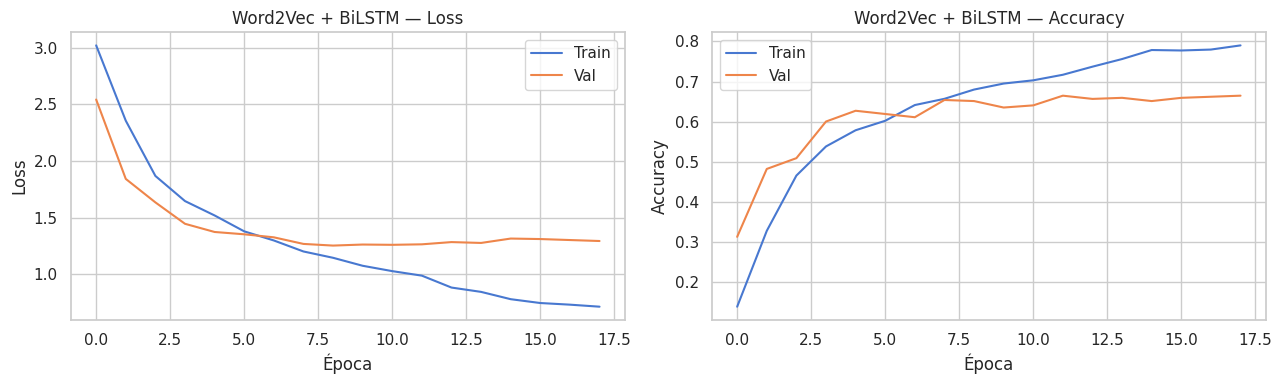

In [10]:
def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, metric, ylabel in zip(
        axes,
        [('loss', 'val_loss'), ('accuracy', 'val_accuracy')],
        ['Loss', 'Accuracy']
    ):
        ax.plot(history.history[metric[0]], label='Train')
        ax.plot(history.history[metric[1]], label='Val')
        ax.set_xlabel('Época')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{model_name} — {ylabel}')
        ax.legend()
    plt.tight_layout()
    plt.show()

plot_training_history(history_bilstm, 'Word2Vec + BiLSTM')

### 4.6 Evaluación BiLSTM


=== Word2Vec + BiLSTM — Métricas en TEST ===
  Accuracy    : 0.6863
  Precision   : 0.6733
  Recall      : 0.6863
  F1          : 0.6712
  ROC-AUC     : 0.9487

                         precision    recall  f1-score   support

            ACCOUNTANT       0.94      0.94      0.94        17
              ADVOCATE       0.68      0.76      0.72        17
           AGRICULTURE       0.00      0.00      0.00        10
               APPAREL       0.25      0.14      0.18        14
                  ARTS       0.33      0.19      0.24        16
            AUTOMOBILE       0.00      0.00      0.00         5
              AVIATION       0.32      0.50      0.39        18
               BANKING       0.42      0.61      0.50        18
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.75      1.00      0.86        18
                  CHEF       0.93      0.76      0.84        17
          CONSTRUCTION       1.00      0.82      0.90        17
    

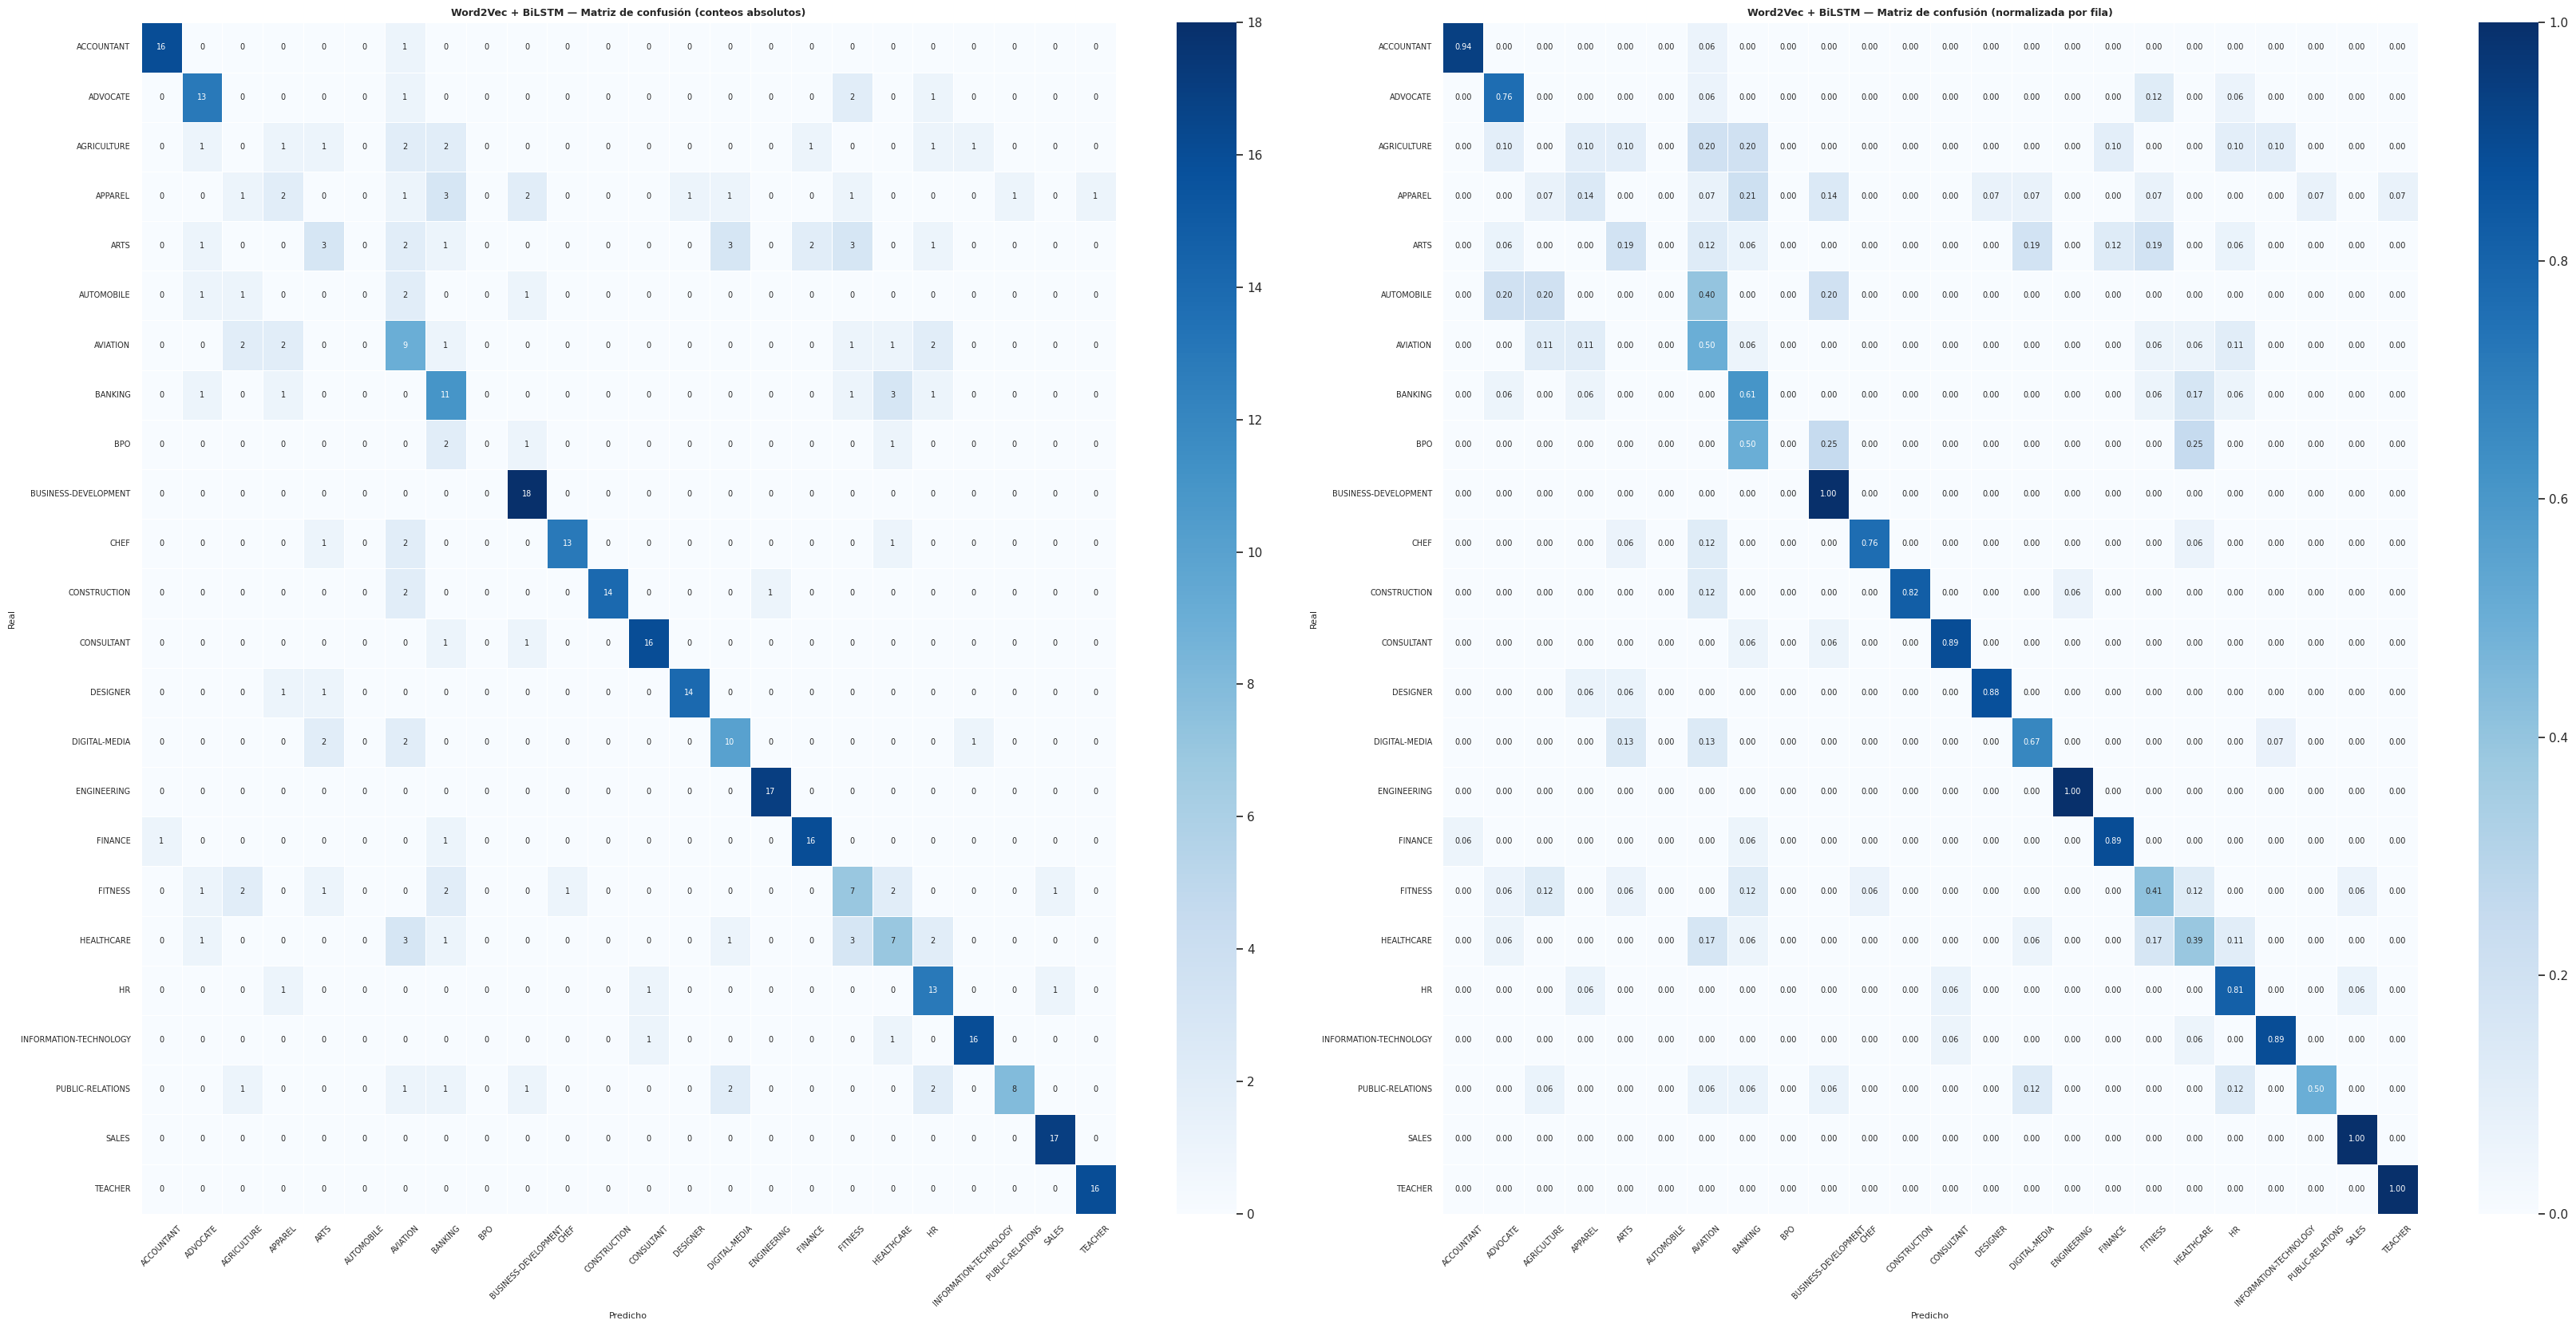

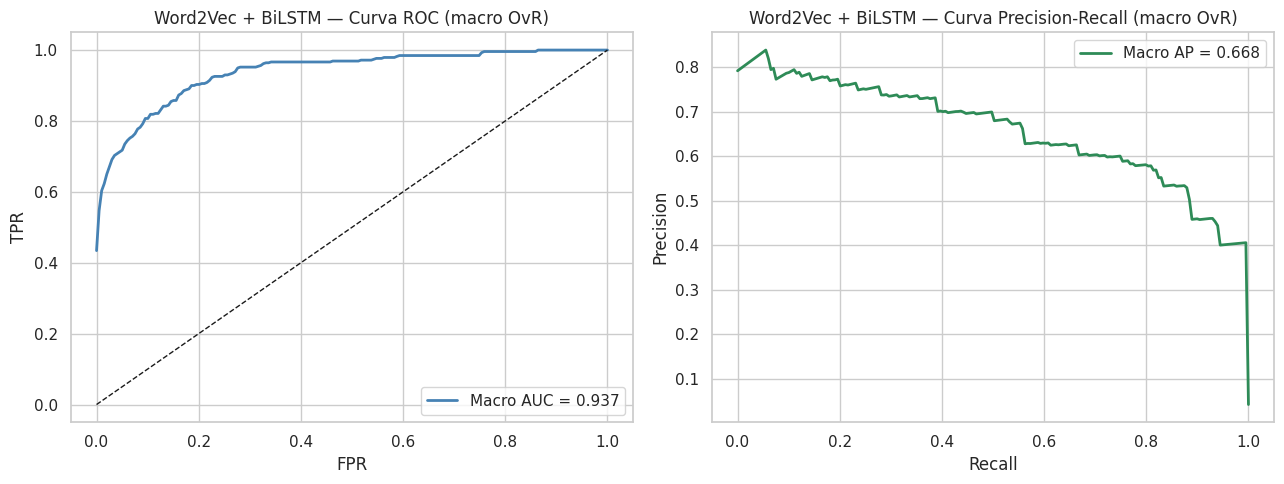

In [11]:
y_proba_bilstm = bilstm_model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
y_pred_bilstm  = np.argmax(y_proba_bilstm, axis=1)

metrics_bilstm = evaluate_model(
    y_test, y_pred_bilstm, y_proba_bilstm, CLASSES, 'Word2Vec + BiLSTM'
)
results_table['Word2Vec + BiLSTM'] = metrics_bilstm

In [12]:
bilstm_model.save('models/bilstm_w2v.keras')
print('Modelo guardado: models/bilstm_w2v.keras')

Modelo guardado: models/bilstm_w2v.keras


---
## Modelo 5: DistilBERT
Sección 11.20.6.3, posición 1. Se descarga el modelo preentrenado `distilbert-base-uncased` desde HuggingFace Hub (gratuito, ~260 MB).

### 5.1 Preparación del tokenizador DistilBERT

In [13]:
BERT_MODEL_NAME = 'distilbert-base-uncased'
BERT_MAX_LEN    = 128    # DistilBERT soporta hasta 512; 128 balancea velocidad/precisión
BERT_BATCH_SIZE = 32
BERT_EPOCHS     = 10
BERT_LR         = 2e-5  # tasa estándar para fine-tuning de Transformers

print(f'Cargando tokenizador: {BERT_MODEL_NAME}')
bert_tokenizer = DistilBertTokenizerFast.from_pretrained(BERT_MODEL_NAME)
print('Tokenizador cargado.')

Cargando tokenizador: distilbert-base-uncased
Tokenizador cargado.


### 5.2 Tokenización del dataset para DistilBERT

In [14]:
def tokenize_for_bert(texts, tokenizer, max_len):
    """
    Tokeniza textos con el tokenizador de HuggingFace y retorna
    un tf.data.Dataset listo para entrenamiento con TF.
    """
    encoded = tokenizer(
        list(texts),
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='np'
    )
    return encoded['input_ids'], encoded['attention_mask']


print('Tokenizando train...')
ids_train, mask_train = tokenize_for_bert(text_train, bert_tokenizer, BERT_MAX_LEN)
print('Tokenizando val...')
ids_val,   mask_val   = tokenize_for_bert(text_val,   bert_tokenizer, BERT_MAX_LEN)
print('Tokenizando test...')
ids_test,  mask_test  = tokenize_for_bert(text_test,  bert_tokenizer, BERT_MAX_LEN)

print(f'\nShapes — input_ids   train: {ids_train.shape}')
print(f'         attention_mask train: {mask_train.shape}')

Tokenizando train...
Tokenizando val...
Tokenizando test...

Shapes — input_ids   train: (1738, 128)
         attention_mask train: (1738, 128)


In [15]:
# Construir tf.data.Dataset para mayor eficiencia con GPU
def make_tf_dataset(input_ids, attention_mask, labels, batch_size, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((
        {'input_ids': input_ids, 'attention_mask': attention_mask},
        labels
    ))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(labels), seed=RANDOM_SEED)
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)


ds_train = make_tf_dataset(ids_train, mask_train, y_train, BERT_BATCH_SIZE, shuffle=True)
ds_val   = make_tf_dataset(ids_val,   mask_val,   y_val,   BERT_BATCH_SIZE)
ds_test  = make_tf_dataset(ids_test,  mask_test,  y_test,  BERT_BATCH_SIZE)

print('tf.data.Datasets creados.')

tf.data.Datasets creados.


### 5.3 Carga del modelo preentrenado y fine-tuning

In [16]:
print(f'Cargando {BERT_MODEL_NAME} preentrenado (~260 MB desde HuggingFace Hub)...')
bert_model = TFDistilBertForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=NUM_CLASSES,
    use_safetensors=False
)
print('Modelo cargado.')
print(f'Parámetros totales: {bert_model.count_params():,}')

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


Cargando distilbert-base-uncased preentrenado (~260 MB desde HuggingFace Hub)...


Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['activation_13', 'vocab_layer_norm', 'vocab_transform', 'vocab_projector']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['dropout_21', 'pre_classifier', 'classifier']
You should probably TRAIN this model on a down-stream task to be able to use i

Modelo cargado.
Parámetros totales: 66,971,928


In [17]:
# Número de pasos de entrenamiento para el scheduler lineal
num_train_steps    = (len(y_train) // BERT_BATCH_SIZE) * BERT_EPOCHS
num_warmup_steps   = num_train_steps // 10  # 10% de warmup

# Optimizer con warmup lineal (estándar en fine-tuning de Transformers)
optimizer, lr_schedule = create_optimizer(
    init_lr=BERT_LR,
    num_train_steps=num_train_steps,
    num_warmup_steps=num_warmup_steps
)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

bert_model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

cbs_bert = [
    tf_keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=3,
        restore_best_weights=True, verbose=1
    )
]

print(f'Pasos de entrenamiento  : {num_train_steps}')
print(f'Pasos de warmup         : {num_warmup_steps}')
print(f'\nIniciando fine-tuning DistilBERT...')

history_bert = bert_model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=BERT_EPOCHS,
    callbacks=cbs_bert,
    verbose=1
)

Pasos de entrenamiento  : 540
Pasos de warmup         : 54

Iniciando fine-tuning DistilBERT...
Epoch 1/10
55/55 [==============================] - 36s 374ms/step - loss: 3.1633 - accuracy: 0.0593 - val_loss: 3.0727 - val_accuracy: 0.1528
Epoch 2/10
55/55 [==============================] - 17s 310ms/step - loss: 2.7495 - accuracy: 0.4609 - val_loss: 2.2661 - val_accuracy: 0.6515
Epoch 3/10
55/55 [==============================] - 19s 348ms/step - loss: 1.9832 - accuracy: 0.7112 - val_loss: 1.6503 - val_accuracy: 0.7212
Epoch 4/10
55/55 [==============================] - 17s 305ms/step - loss: 1.4953 - accuracy: 0.7670 - val_loss: 1.3648 - val_accuracy: 0.7346
Epoch 5/10
55/55 [==============================] - 17s 310ms/step - loss: 1.2057 - accuracy: 0.7992 - val_loss: 1.1967 - val_accuracy: 0.7373
Epoch 6/10
55/55 [==============================] - 19s 343ms/step - loss: 1.0306 - accuracy: 0.8251 - val_loss: 1.1150 - val_accuracy: 0.7453
Epoch 7/10
55/55 [============================

### 5.4 Curvas de entrenamiento DistilBERT

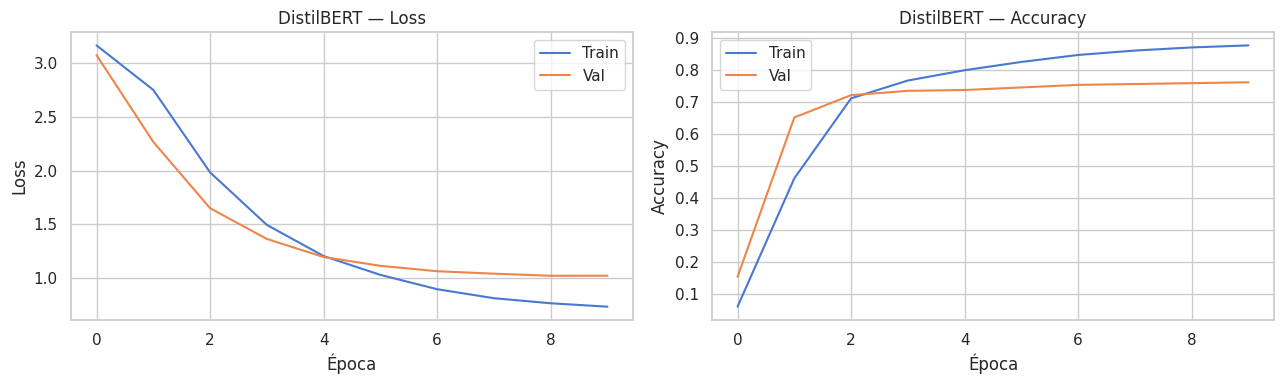

In [18]:
def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, metric, ylabel in zip(
        axes,
        [('loss', 'val_loss'), ('accuracy', 'val_accuracy')],
        ['Loss', 'Accuracy']
    ):
        ax.plot(history.history[metric[0]], label='Train')
        ax.plot(history.history[metric[1]], label='Val')
        ax.set_xlabel('Época')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{model_name} — {ylabel}')
        ax.legend()
    plt.tight_layout()
    plt.show()
plot_training_history(history_bert, 'DistilBERT')

### 5.5 Evaluación DistilBERT

Generando predicciones en test set...
12/12 [==============================] - 0s 111ms/step

=== DistilBERT — Métricas en TEST ===
  Accuracy    : 0.7855
  Precision   : 0.7699
  Recall      : 0.7855
  F1          : 0.7672
  ROC-AUC     : 0.9689

                         precision    recall  f1-score   support

            ACCOUNTANT       0.89      1.00      0.94        17
              ADVOCATE       1.00      0.82      0.90        17
           AGRICULTURE       0.67      0.20      0.31        10
               APPAREL       0.60      0.21      0.32        14
                  ARTS       0.53      0.50      0.52        16
            AUTOMOBILE       0.00      0.00      0.00         5
              AVIATION       0.65      0.83      0.73        18
               BANKING       0.75      0.83      0.79        18
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.95      1.00      0.97        18
                  CHEF       0.93      0.76   

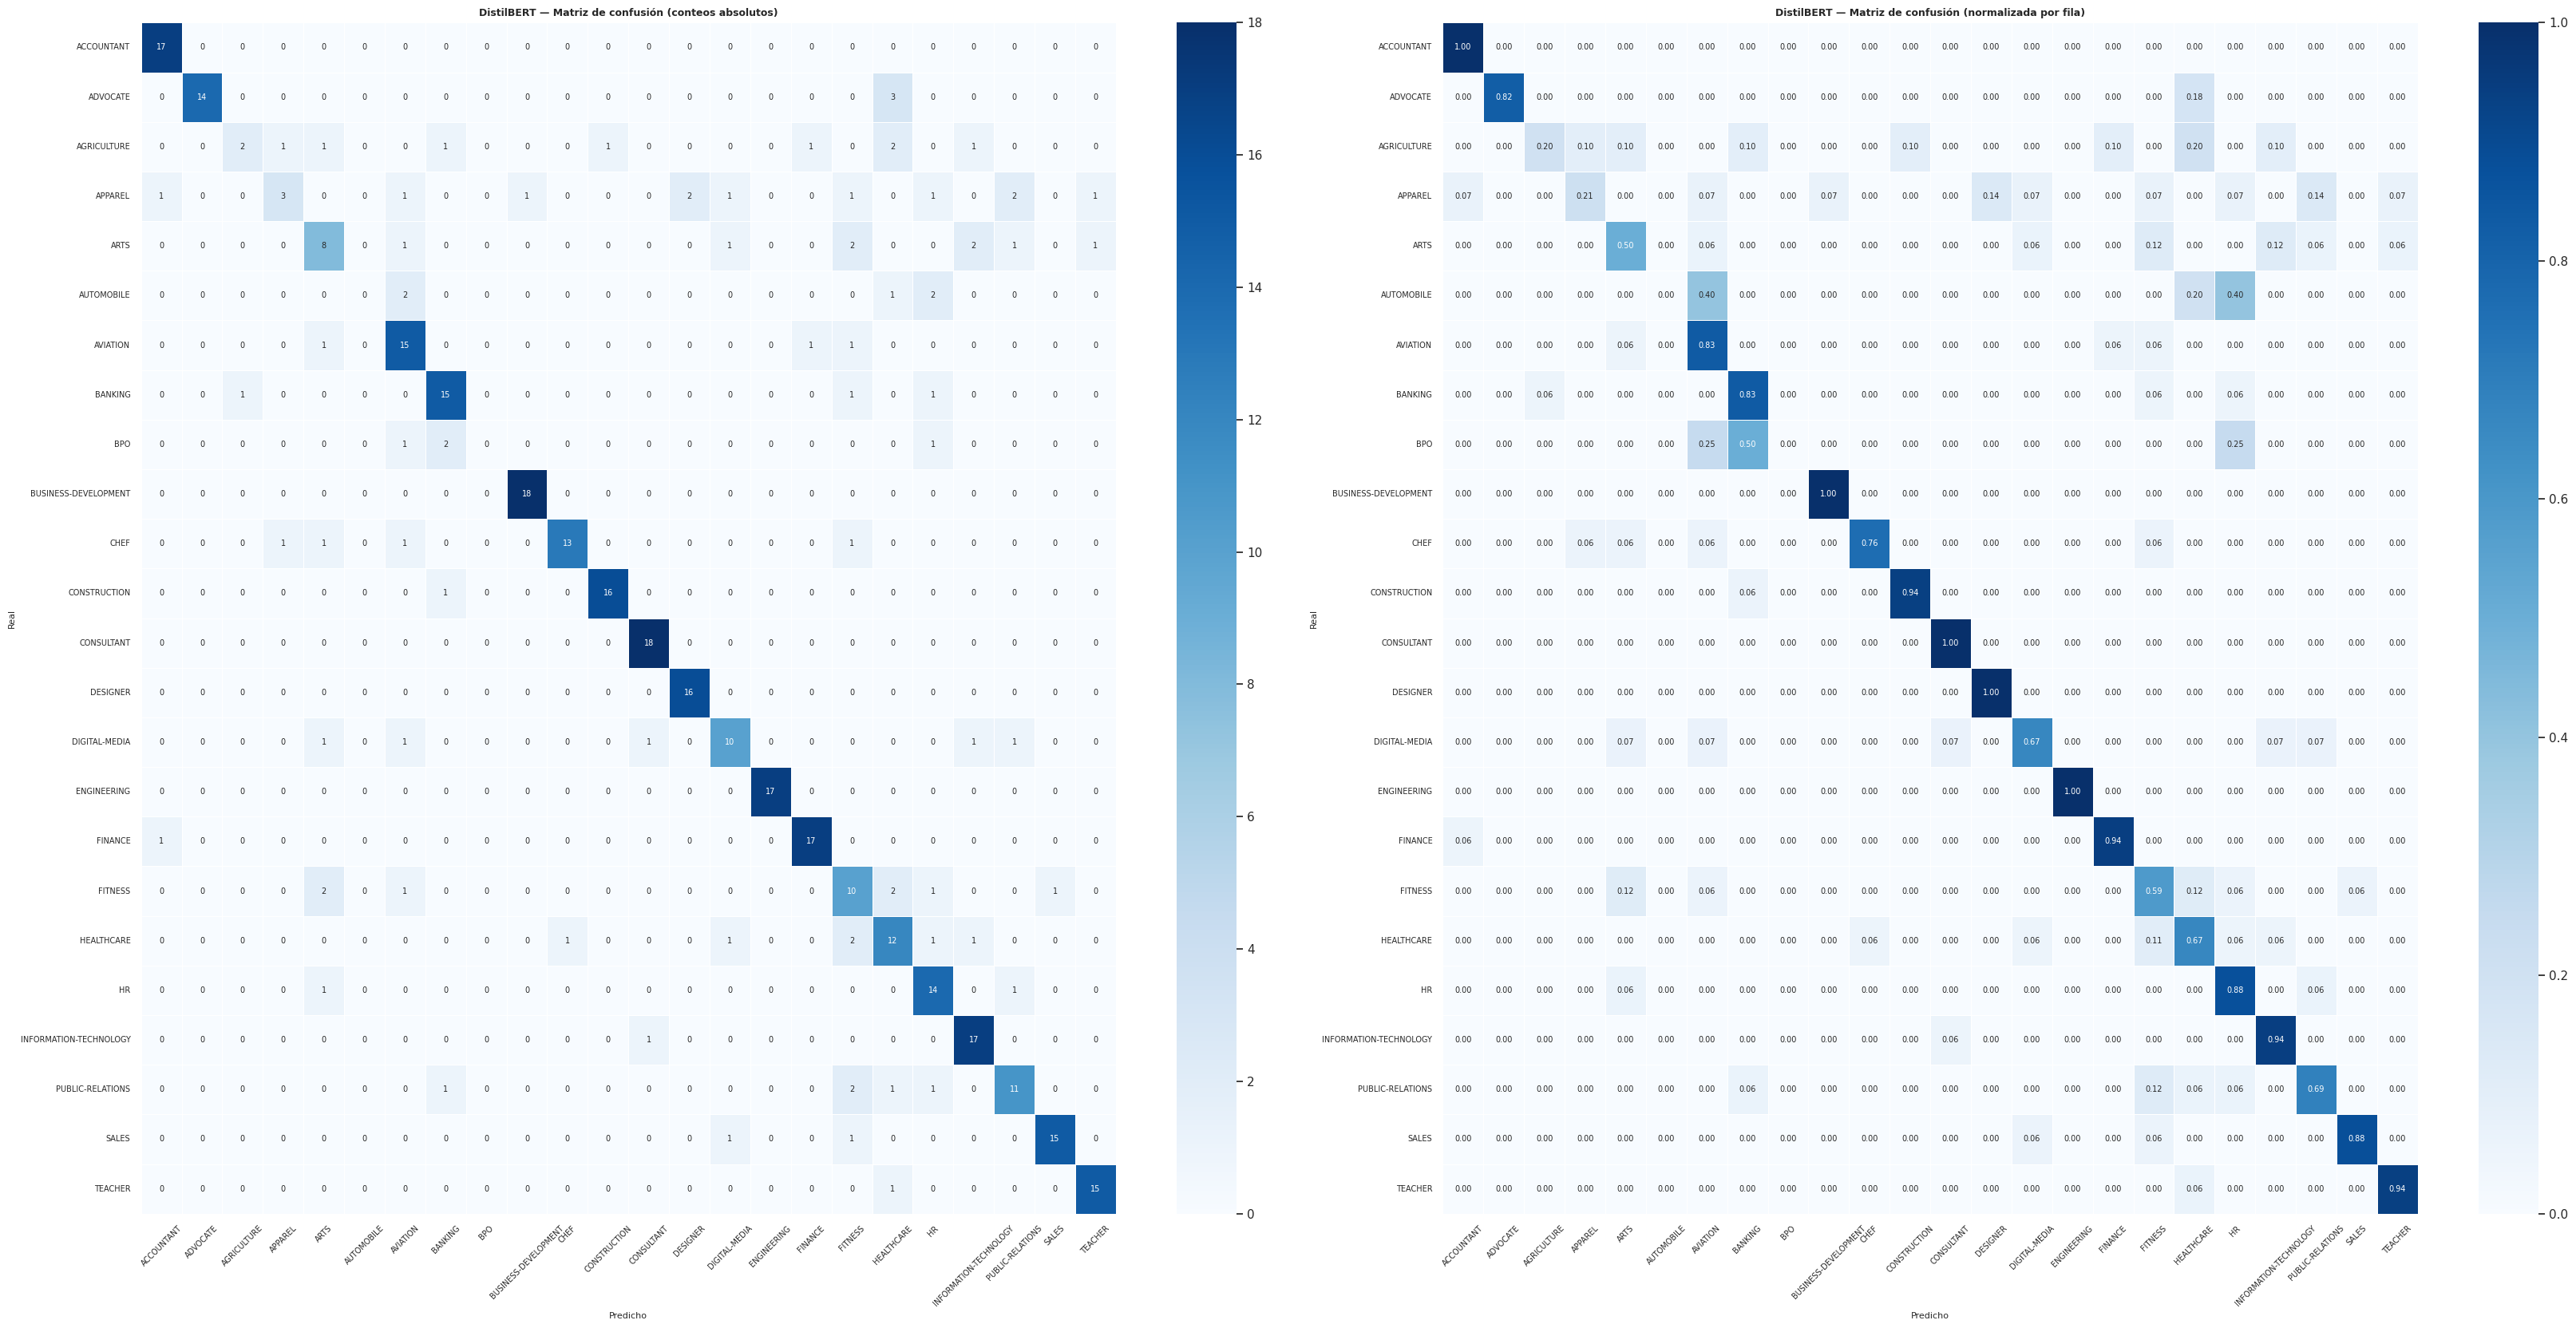

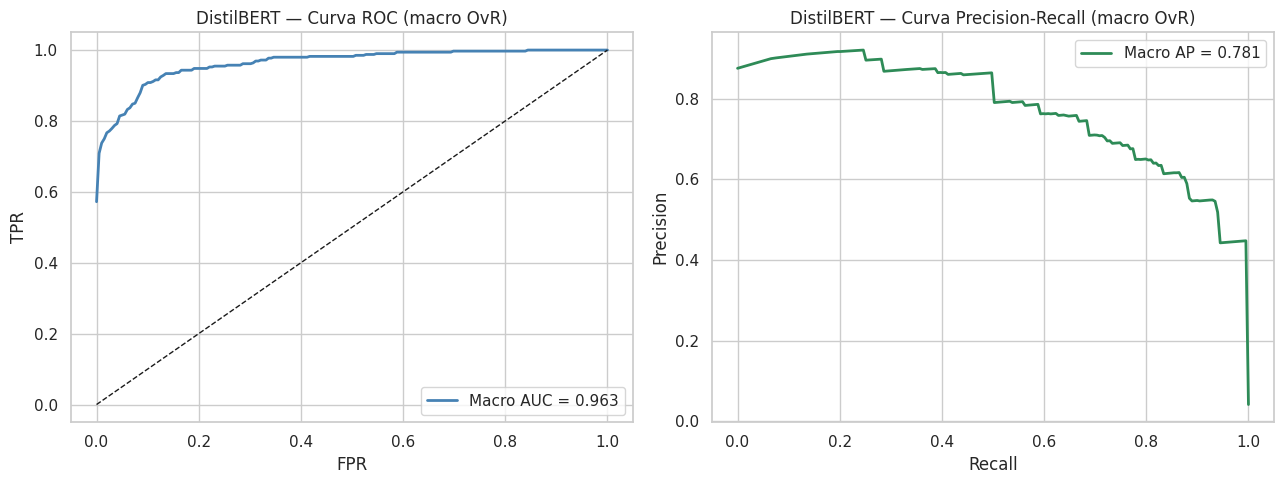

In [19]:
# DistilBERT retorna logits → convertir a probabilidades
print('Generando predicciones en test set...')
logits_test = bert_model.predict(ds_test, verbose=1).logits
y_proba_bert = tf.nn.softmax(logits_test, axis=-1).numpy()
y_pred_bert  = np.argmax(y_proba_bert, axis=1)

metrics_bert = evaluate_model(
    y_test, y_pred_bert, y_proba_bert, CLASSES, 'DistilBERT'
)
results_table['DistilBERT'] = metrics_bert

In [20]:
bert_model.save_pretrained('models/distilbert_finetuned')
bert_tokenizer.save_pretrained('models/distilbert_finetuned')
print('Modelo guardado en: models/distilbert_finetuned/')

Modelo guardado en: models/distilbert_finetuned/


---
## 6. Tabla comparativa final — 5 modelos
Sección 11.20.6.8 del PDF.

In [21]:
print('results_table inicializado con métricas del notebook 02.')
results_df = pd.DataFrame(results_table).T.round(4)
results_df.index.name = 'Modelo'

# Ordenar por F1 descendente
results_df = results_df.sort_values('F1', ascending=False)

print('=== TABLA COMPARATIVA FINAL — TEST SET (5 modelos) ===')
print(results_df.to_string())
results_df

results_table inicializado con métricas del notebook 02.
=== TABLA COMPARATIVA FINAL — TEST SET (5 modelos) ===
                    Accuracy  Precision  Recall      F1  ROC-AUC
Modelo                                                          
DistilBERT            0.7855     0.7699  0.7855  0.7672   0.9689
CNN-1D                0.7212     0.7101  0.7212  0.6965   0.9496
Word2Vec + BiLSTM     0.6863     0.6733  0.6863  0.6712   0.9487
FastText + XGBoost    0.5255     0.5261  0.5255  0.5044   0.8968
TF-IDF + XGBoost      0.4477     0.4478  0.4477  0.3670   0.7943


,Accuracy,Precision,Recall,F1,ROC-AUC
Modelo,,,,,
DistilBERT,0.7855,0.7699,0.7855,0.7672,0.9689
CNN-1D,0.7212,0.7101,0.7212,0.6965,0.9496
Word2Vec + BiLSTM,0.6863,0.6733,0.6863,0.6712,0.9487
FastText + XGBoost,0.5255,0.5261,0.5255,0.5044,0.8968
TF-IDF + XGBoost,0.4477,0.4478,0.4477,0.3670,0.7943


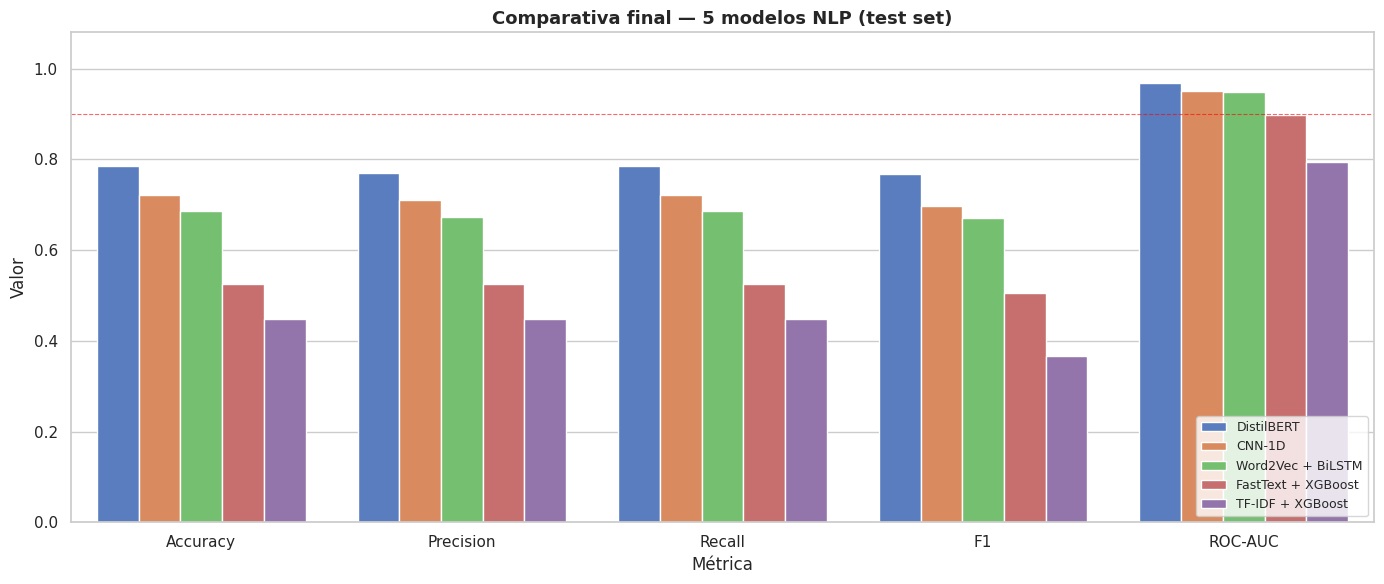

In [22]:
# Barplot comparativo de todos los modelos
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
plot_df = results_df[metrics_to_plot].reset_index().melt(
    id_vars='Modelo', var_name='Métrica', value_name='Valor'
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=plot_df, x='Métrica', y='Valor',
    hue='Modelo', palette='muted', ax=ax
)
ax.set_ylim(0, 1.08)
ax.set_title('Comparativa final — 5 modelos NLP (test set)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)

# Línea de referencia en 0.9
ax.axhline(0.9, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='0.90')
plt.tight_layout()
plt.show()

---
## 7. Análisis crítico (Sección 11.20.6.9)

**¿Transformers vs modelos clásicos?**  
→ DistilBERT captura contexto bidireccional y semántica profunda que TF-IDF y FastText no pueden. La diferencia en F1 refleja esta brecha, especialmente en clases con textos similares.

**¿Impacto del preprocesamiento?**  
→ TF-IDF y BiLSTM dependen directamente del texto limpio del EDA. DistilBERT es más robusto al ruido ya que su tokenizador WordPiece maneja subpalabras y texto sin normalizar.

**¿Errores comunes?**  
→ Revisar la diagonal de la matriz de confusión por modelo. Las categorías con menor soporte (pocas muestras) tendrán peor Recall independientemente del modelo.

**Completa con tus observaciones numéricas una vez ejecutado el notebook.**